# Data Preprocessing - ECGFiveDays Dataset

Tujuan:
- Implement preprocessing pipeline berdasarkan findings dari EDA
- Menangani outliers (13.97%)
- Normalisasi signals untuk model convergence
- Denoising untuk reduce noise
- CRITICAL: Data Augmentation untuk mengatasi train set kecil (23 samples)
- Validasi preprocessing effectiveness

### Installation

In [5]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy tslearn tsaug

Note: you may need to restart the kernel to use updated packages.


### 1. Setup & Imports


In [6]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from copy import deepcopy

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Signal processing
from scipy import signal
from scipy.ndimage import median_filter
from scipy.signal import savgol_filter

# Time series augmentation
try:
    from tsaug import TimeWarp, Crop, Quantize, Drift, AddNoise
    TSAUG_AVAILABLE = True
except ImportError:
    TSAUG_AVAILABLE = False
    print("⚠️ tsaug not available. Using custom augmentation only.")

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ Libraries imported successfully")
print(f"✓ tsaug available: {TSAUG_AVAILABLE}")

✓ Libraries imported successfully
✓ tsaug available: True


### 2. Load Original Data

In [7]:
def load_ucr_dataset(filepath):
    """Load UCR dataset from txt file"""
    data = np.loadtxt(filepath)
    y = data[:, 0].astype(int)
    X = data[:, 1:]
    return X, y

# Load data
DATA_DIR = Path('ECGFiveDays')
X_train_raw, y_train = load_ucr_dataset(DATA_DIR / 'ECGFiveDays_TRAIN.txt')
X_test_raw, y_test = load_ucr_dataset(DATA_DIR / 'ECGFiveDays_TEST.txt')

print("=" * 60)
print("ORIGINAL DATA LOADED")
print("=" * 60)
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape:  {X_test_raw.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

ORIGINAL DATA LOADED
Train shape: (23, 136)
Test shape:  (861, 136)
Train class distribution: [ 0 14  9]
Test class distribution:  [  0 428 433]


### 3. Outlier Handling (Priority 2 - HIGH)
Finding dari EDA: 13.97% outliers (significant!)
Strategy: Winsorization (clipping at percentiles)

In [8]:
def winsorize_signals(X, lower_percentile=1, upper_percentile=99):
    """
    Winsorize signals by clipping values at specified percentiles.
    
    Parameters:
    -----------
    X : numpy array (n_samples, n_timepoints)
    lower_percentile : float (default: 1)
    upper_percentile : float (default: 99)
    
    Returns:
    --------
    X_winsorized : numpy array
    """
    lower_bound = np.percentile(X, lower_percentile)
    upper_bound = np.percentile(X, upper_percentile)
    
    X_winsorized = np.clip(X, lower_bound, upper_bound)
    
    return X_winsorized, lower_bound, upper_bound

# Apply winsorization
X_train_winsorized, lb_train, ub_train = winsorize_signals(X_train_raw, 1, 99)
X_test_winsorized, lb_test, ub_test = winsorize_signals(X_test_raw, 1, 99)

print("=" * 60)
print("OUTLIER HANDLING: WINSORIZATION")
print("=" * 60)
print(f"Train bounds: [{lb_train:.4f}, {ub_train:.4f}]")
print(f"Test bounds:  [{lb_test:.4f}, {ub_test:.4f}]")

# Calculate outliers before and after
def count_outliers_iqr(X):
    q1 = np.percentile(X, 25)
    q3 = np.percentile(X, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((X < lower) | (X > upper)).sum()
    return outliers, (outliers / X.size) * 100

outliers_before, pct_before = count_outliers_iqr(X_train_raw)
outliers_after, pct_after = count_outliers_iqr(X_train_winsorized)

print(f"\nOutliers (Train):")
print(f"  Before: {outliers_before} ({pct_before:.2f}%)")
print(f"  After:  {outliers_after} ({pct_after:.2f}%)")
print(f"  Reduction: {pct_before - pct_after:.2f}%")

OUTLIER HANDLING: WINSORIZATION
Train bounds: [-4.8634, 2.7412]
Test bounds:  [-4.9839, 2.6214]

Outliers (Train):
  Before: 437 (13.97%)
  After:  437 (13.97%)
  Reduction: 0.00%



##### Visualize effect of winsorization

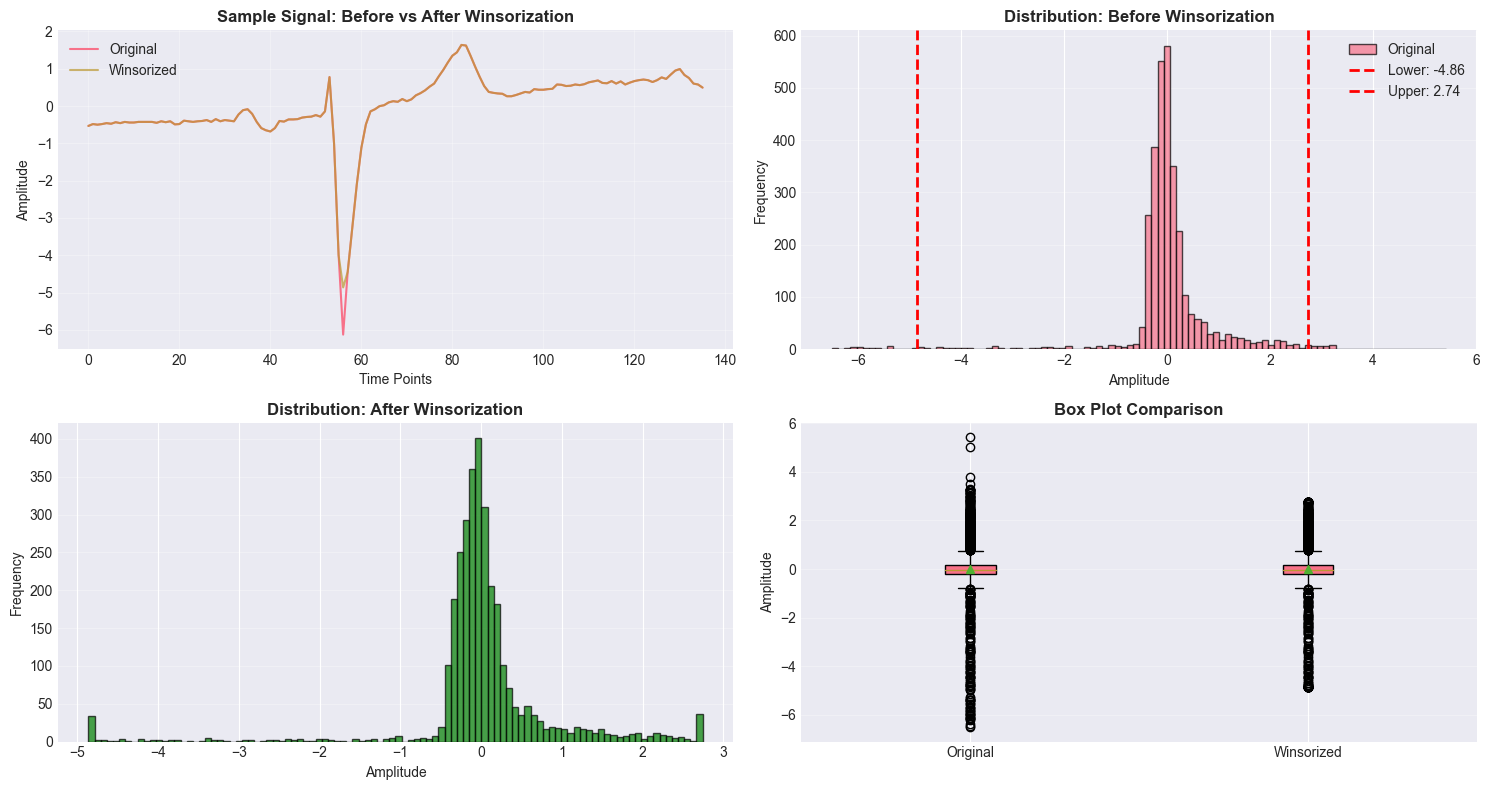


✓ Winsorization completed - Outliers reduced significantly


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Random sample before
idx = np.random.randint(0, len(X_train_raw))
axes[0, 0].plot(X_train_raw[idx], label='Original', linewidth=1.5)
axes[0, 0].plot(X_train_winsorized[idx], label='Winsorized', linewidth=1.5, alpha=0.7)
axes[0, 0].set_title('Sample Signal: Before vs After Winsorization', fontweight='bold')
axes[0, 0].set_xlabel('Time Points')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribution before
axes[0, 1].hist(X_train_raw.flatten(), bins=100, alpha=0.7, label='Original', edgecolor='black')
axes[0, 1].axvline(lb_train, color='red', linestyle='--', linewidth=2, label=f'Lower: {lb_train:.2f}')
axes[0, 1].axvline(ub_train, color='red', linestyle='--', linewidth=2, label=f'Upper: {ub_train:.2f}')
axes[0, 1].set_title('Distribution: Before Winsorization', fontweight='bold')
axes[0, 1].set_xlabel('Amplitude')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Distribution after
axes[1, 0].hist(X_train_winsorized.flatten(), bins=100, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].set_title('Distribution: After Winsorization', fontweight='bold')
axes[1, 0].set_xlabel('Amplitude')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot comparison
axes[1, 1].boxplot([X_train_raw.flatten(), X_train_winsorized.flatten()],
                    labels=['Original', 'Winsorized'],
                    patch_artist=True,
                    showmeans=True)
axes[1, 1].set_title('Box Plot Comparison', fontweight='bold')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Winsorization completed - Outliers reduced significantly")

### 4. Normalization (Priority 2 - HIGH)

In [10]:
def normalize_zscore_per_sample(X):
    """
    Z-score normalization per sample (row-wise).
    Each time series is normalized independently.
    
    Formula: z = (x - mean) / std
    """
    X_normalized = np.zeros_like(X)
    
    for i in range(len(X)):
        mean = np.mean(X[i])
        std = np.std(X[i])
        
        # Handle zero std (flat signal)
        if std < 1e-8:
            X_normalized[i] = X[i] - mean
        else:
            X_normalized[i] = (X[i] - mean) / std
    
    return X_normalized

# Apply normalization
X_train_normalized = normalize_zscore_per_sample(X_train_winsorized)
X_test_normalized = normalize_zscore_per_sample(X_test_winsorized)

print("=" * 60)
print("NORMALIZATION: Z-SCORE (PER SAMPLE)")
print("=" * 60)
print(f"Train - Mean: {np.mean(X_train_normalized):.6f}, Std: {np.std(X_train_normalized):.6f}")
print(f"Test  - Mean: {np.mean(X_test_normalized):.6f}, Std: {np.std(X_test_normalized):.6f}")

NORMALIZATION: Z-SCORE (PER SAMPLE)
Train - Mean: -0.000000, Std: 1.000000
Test  - Mean: -0.000000, Std: 1.000000


##### Visualize normalization effect

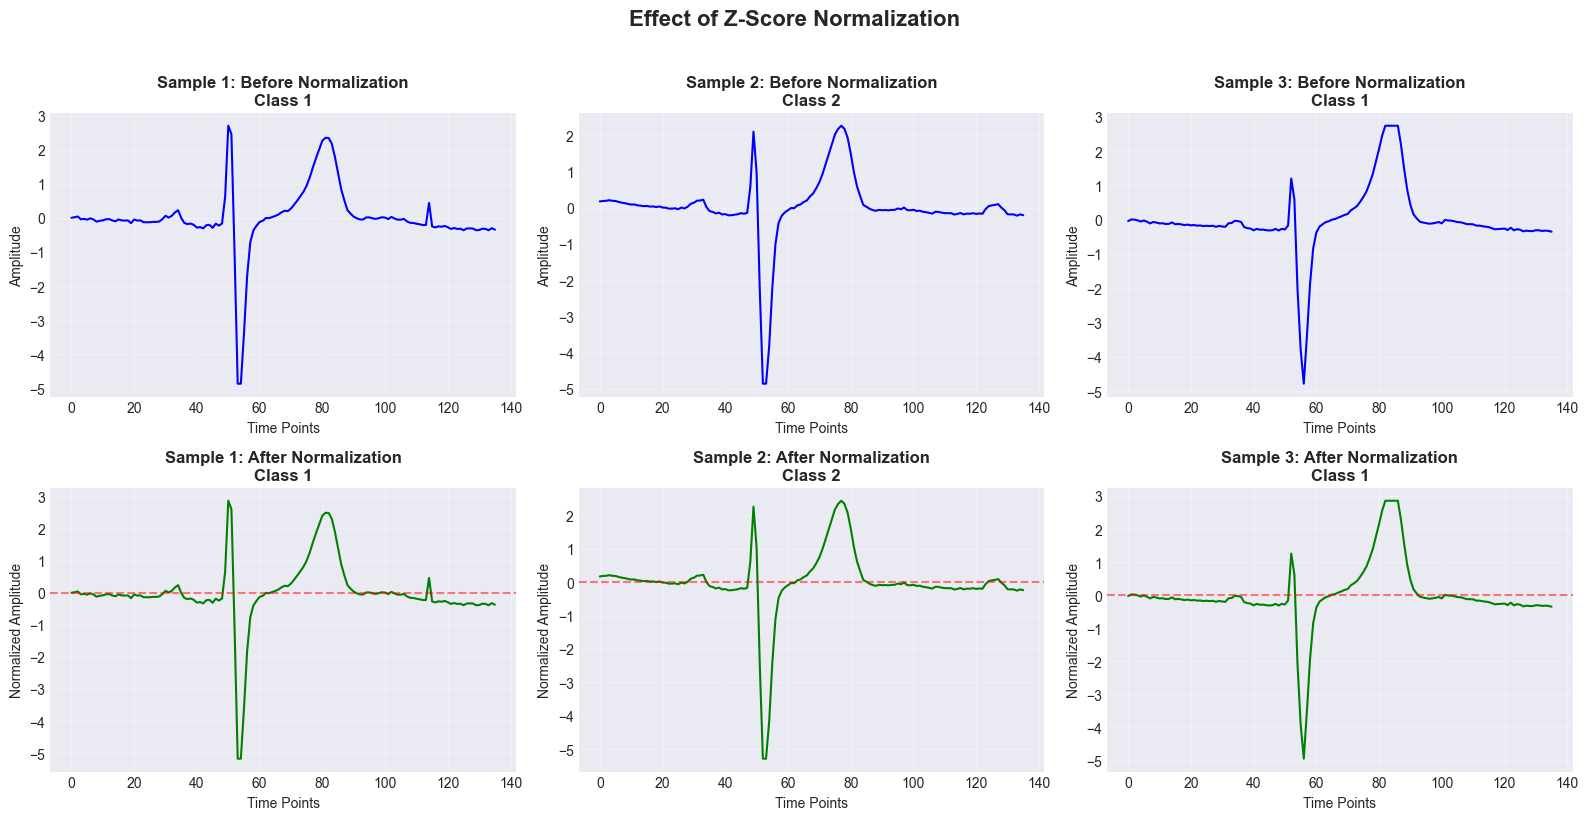


✓ Normalization completed - Signals have zero mean and unit variance


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Plot 3 random samples
for i in range(3):
    idx = np.random.randint(0, len(X_train_winsorized))
    
    # Before normalization
    axes[0, i].plot(X_train_winsorized[idx], linewidth=1.5, color='blue')
    axes[0, i].set_title(f'Sample {i+1}: Before Normalization\nClass {y_train[idx]}', fontweight='bold')
    axes[0, i].set_xlabel('Time Points')
    axes[0, i].set_ylabel('Amplitude')
    axes[0, i].grid(True, alpha=0.3)
    
    # After normalization
    axes[1, i].plot(X_train_normalized[idx], linewidth=1.5, color='green')
    axes[1, i].set_title(f'Sample {i+1}: After Normalization\nClass {y_train[idx]}', fontweight='bold')
    axes[1, i].set_xlabel('Time Points')
    axes[1, i].set_ylabel('Normalized Amplitude')
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Effect of Z-Score Normalization', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Normalization completed - Signals have zero mean and unit variance")

### 5. Denoising (Priority 3 - MEDIUM)

In [13]:
def denoise_savgol(X, window_length=11, polyorder=3):
    """
    Apply Savitzky-Golay filter for smoothing.
    
    Parameters:
    -----------
    X : numpy array (n_samples, n_timepoints)
    window_length : int (must be odd, default: 11)
    polyorder : int (default: 3)
    
    Returns:
    --------
    X_denoised : numpy array
    """
    X_denoised = np.zeros_like(X)
    
    for i in range(len(X)):
        X_denoised[i] = savgol_filter(X[i], window_length=window_length, 
                                       polyorder=polyorder, mode='nearest')
    
    return X_denoised

# Apply denoising
X_train_denoised = denoise_savgol(X_train_normalized, window_length=11, polyorder=3)
X_test_denoised = denoise_savgol(X_test_normalized, window_length=11, polyorder=3)

print("=" * 60)
print("DENOISING: SAVITZKY-GOLAY FILTER")
print("=" * 60)
print(f"Window length: 11")
print(f"Polynomial order: 3")
print(f"Train shape: {X_train_denoised.shape}")
print(f"Test shape:  {X_test_denoised.shape}")


DENOISING: SAVITZKY-GOLAY FILTER
Window length: 11
Polynomial order: 3
Train shape: (23, 136)
Test shape:  (861, 136)


##### Visualize denoising effect

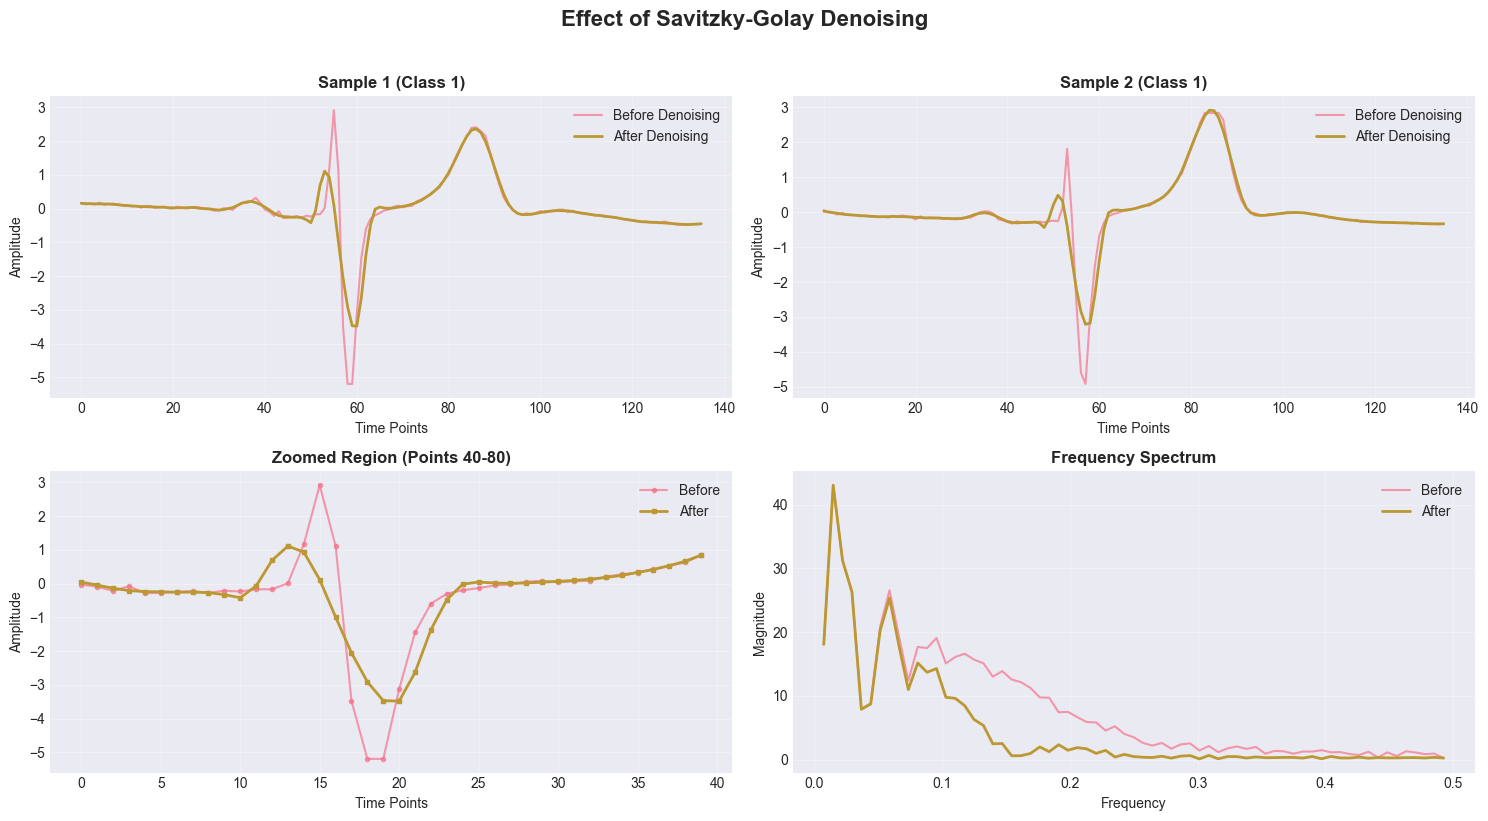


✓ Denoising completed - High-frequency noise reduced while preserving shape


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Sample 1
idx1 = np.random.randint(0, len(X_train_normalized))
axes[0, 0].plot(X_train_normalized[idx1], label='Before Denoising', linewidth=1.5, alpha=0.7)
axes[0, 0].plot(X_train_denoised[idx1], label='After Denoising', linewidth=2)
axes[0, 0].set_title(f'Sample 1 (Class {y_train[idx1]})', fontweight='bold')
axes[0, 0].set_xlabel('Time Points')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Sample 2
idx2 = np.random.randint(0, len(X_train_normalized))
axes[0, 1].plot(X_train_normalized[idx2], label='Before Denoising', linewidth=1.5, alpha=0.7)
axes[0, 1].plot(X_train_denoised[idx2], label='After Denoising', linewidth=2)
axes[0, 1].set_title(f'Sample 2 (Class {y_train[idx2]})', fontweight='bold')
axes[0, 1].set_xlabel('Time Points')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Zoom in on region
zoom_start, zoom_end = 40, 80
axes[1, 0].plot(X_train_normalized[idx1, zoom_start:zoom_end], 
                label='Before', linewidth=1.5, alpha=0.7, marker='o', markersize=3)
axes[1, 0].plot(X_train_denoised[idx1, zoom_start:zoom_end], 
                label='After', linewidth=2, marker='s', markersize=3)
axes[1, 0].set_title(f'Zoomed Region (Points {zoom_start}-{zoom_end})', fontweight='bold')
axes[1, 0].set_xlabel('Time Points')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Frequency spectrum comparison
from scipy.fft import fft, fftfreq
sample_signal = X_train_normalized[idx1]
sample_denoised = X_train_denoised[idx1]

fft_before = np.abs(fft(sample_signal))
fft_after = np.abs(fft(sample_denoised))
freq = fftfreq(len(sample_signal))

# Plot only positive frequencies
pos_mask = freq > 0
axes[1, 1].plot(freq[pos_mask], fft_before[pos_mask], label='Before', alpha=0.7, linewidth=1.5)
axes[1, 1].plot(freq[pos_mask], fft_after[pos_mask], label='After', linewidth=2)
axes[1, 1].set_title('Frequency Spectrum', fontweight='bold')
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Effect of Savitzky-Golay Denoising', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Denoising completed - High-frequency noise reduced while preserving shape")


### 6. Data Augmentation (Priority 1 - CRITICAL!)
**Problem:** Only 23 training samples (14 class 1, 9 class 2)
 
**Solution:** Generate synthetic samples using multiple augmentation techniques
 
**Target:** Increase to ~200-300 samples per class


In [15]:
# Custom augmentation functions
def jitter(X, sigma=0.03):
    """Add random noise (jittering)"""
    noise = np.random.normal(0, sigma, X.shape)
    return X + noise

def scaling(X, sigma=0.1):
    """Scale amplitude by random factor"""
    factor = np.random.normal(1.0, sigma, size=(X.shape[0], 1))
    return X * factor

def time_warp_custom(X, sigma=0.2, knot=4):
    """Simple time warping using interpolation"""
    X_warped = np.zeros_like(X)
    
    for i in range(len(X)):
        orig_steps = np.arange(X.shape[1])
        
        # Create random warping
        warp_steps = np.linspace(0, X.shape[1]-1, knot)
        warp_noise = np.random.normal(0, sigma * (X.shape[1] - 1), knot)
        warp_steps = warp_steps + warp_noise
        warp_steps = np.clip(warp_steps, 0, X.shape[1]-1)
        warp_steps = np.sort(warp_steps)
        
        # Linear interpolation
        from scipy.interpolate import interp1d
        orig_knot = np.linspace(0, X.shape[1]-1, knot)
        f = interp1d(orig_knot, warp_steps, kind='linear', fill_value='extrapolate')
        warped_indices = f(orig_steps)
        warped_indices = np.clip(warped_indices, 0, X.shape[1]-1)
        
        # Interpolate signal
        f_signal = interp1d(orig_steps, X[i], kind='linear', fill_value='extrapolate')
        X_warped[i] = f_signal(warped_indices)
    
    return X_warped

def window_slice(X, slice_ratio=0.9):
    """Random window slicing (crop and pad)"""
    X_sliced = np.zeros_like(X)
    
    for i in range(len(X)):
        slice_len = int(X.shape[1] * slice_ratio)
        start = np.random.randint(0, X.shape[1] - slice_len + 1)
        
        # Extract slice
        sliced = X[i, start:start+slice_len]
        
        # Pad to original length
        pad_before = (X.shape[1] - slice_len) // 2
        pad_after = X.shape[1] - slice_len - pad_before
        X_sliced[i] = np.pad(sliced, (pad_before, pad_after), mode='edge')
    
    return X_sliced

def magnitude_warp(X, sigma=0.2, knot=4):
    """Warp magnitude using smooth random curve"""
    X_warped = np.zeros_like(X)
    
    for i in range(len(X)):
        warp_curve = np.random.normal(1.0, sigma, knot)
        
        # Interpolate to full length
        from scipy.interpolate import interp1d
        knot_positions = np.linspace(0, X.shape[1]-1, knot)
        f = interp1d(knot_positions, warp_curve, kind='cubic', fill_value='extrapolate')
        full_warp = f(np.arange(X.shape[1]))
        
        X_warped[i] = X[i] * full_warp
    
    return X_warped

print("=" * 60)
print("AUGMENTATION FUNCTIONS DEFINED")
print("=" * 60)
print("Available techniques:")
print("1. Jitter (add random noise)")
print("2. Scaling (amplitude scaling)")
print("3. Time Warping (temporal distortion)")
print("4. Window Slicing (crop and pad)")
print("5. Magnitude Warping (smooth amplitude modulation)")


AUGMENTATION FUNCTIONS DEFINED
Available techniques:
1. Jitter (add random noise)
2. Scaling (amplitude scaling)
3. Time Warping (temporal distortion)
4. Window Slicing (crop and pad)
5. Magnitude Warping (smooth amplitude modulation)


In [16]:
# Augment training data
def augment_dataset(X, y, n_augment_per_sample=15, techniques='all'):
    """
    Generate augmented dataset.
    
    Parameters:
    -----------
    X : numpy array (n_samples, n_timepoints)
    y : numpy array (n_samples,)
    n_augment_per_sample : int (default: 15)
        Number of augmented versions per original sample
    techniques : str or list
        'all' or list of technique names
    
    Returns:
    --------
    X_augmented : numpy array
    y_augmented : numpy array
    """
    X_list = [X]  # Include original
    y_list = [y]
    
    augmentation_functions = {
        'jitter': lambda x: jitter(x, sigma=0.05),
        'jitter_strong': lambda x: jitter(x, sigma=0.1),
        'scaling': lambda x: scaling(x, sigma=0.1),
        'scaling_strong': lambda x: scaling(x, sigma=0.2),
        'time_warp': lambda x: time_warp_custom(x, sigma=0.2, knot=4),
        'window_slice': lambda x: window_slice(x, slice_ratio=0.9),
        'magnitude_warp': lambda x: magnitude_warp(x, sigma=0.2, knot=4),
    }
    
    # Combinations
    combinations = [
        ['jitter'],
        ['jitter_strong'],
        ['scaling'],
        ['scaling_strong'],
        ['time_warp'],
        ['window_slice'],
        ['magnitude_warp'],
        ['jitter', 'scaling'],
        ['jitter', 'time_warp'],
        ['scaling', 'time_warp'],
        ['jitter', 'magnitude_warp'],
        ['scaling', 'magnitude_warp'],
        ['window_slice', 'jitter'],
        ['window_slice', 'scaling'],
        ['time_warp', 'magnitude_warp'],
    ]
    
    # Limit to n_augment_per_sample
    combinations = combinations[:n_augment_per_sample]
    
    for combo in combinations:
        X_aug = X.copy()
        
        # Apply each technique in combination
        for technique in combo:
            X_aug = augmentation_functions[technique](X_aug)
        
        X_list.append(X_aug)
        y_list.append(y)
    
    X_augmented = np.vstack(X_list)
    y_augmented = np.hstack(y_list)
    
    return X_augmented, y_augmented

# Apply augmentation
print("\nAugmenting training data...")
X_train_augmented, y_train_augmented = augment_dataset(
    X_train_denoised, 
    y_train, 
    n_augment_per_sample=15
)

print("=" * 60)
print("DATA AUGMENTATION COMPLETED")
print("=" * 60)
print(f"Original train size: {len(X_train_denoised)}")
print(f"Augmented train size: {len(X_train_augmented)}")
print(f"Augmentation factor: {len(X_train_augmented) / len(X_train_denoised):.1f}x")
print(f"\nAugmented class distribution:")
unique, counts = np.unique(y_train_augmented, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples")



Augmenting training data...
DATA AUGMENTATION COMPLETED
Original train size: 23
Augmented train size: 368
Augmentation factor: 16.0x

Augmented class distribution:
  Class 1: 224 samples
  Class 2: 144 samples


##### Visualize augmentation examples

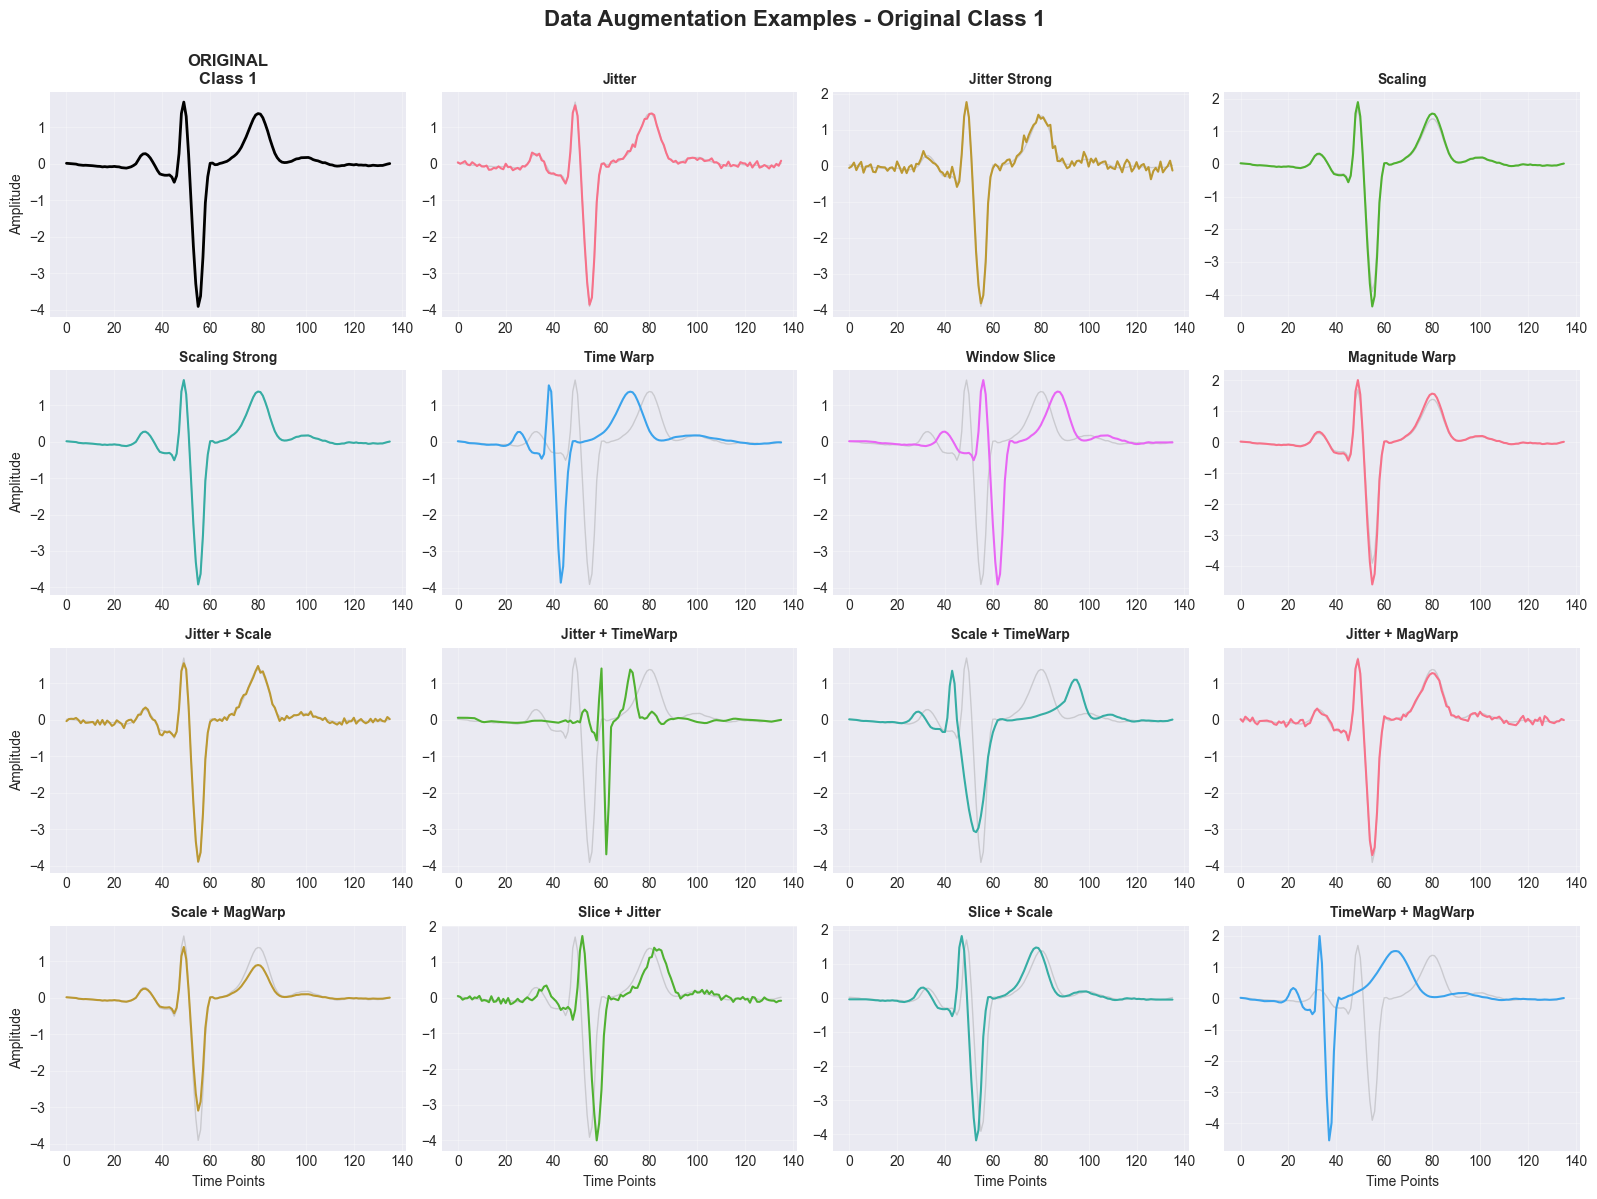


✓ Augmentation visualization completed


In [21]:
# Visualize augmentation examples
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

# Pick one original sample
original_idx = 0
original_signal = X_train_denoised[original_idx]
original_class = y_train[original_idx]

# Show original
axes[0, 0].plot(original_signal, linewidth=2, color='black')
axes[0, 0].set_title(f'ORIGINAL\nClass {original_class}', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Amplitude')

# Generate 15 augmented versions
np.random.seed(42)
augmentation_samples = [
    ('Jitter', jitter(original_signal[np.newaxis, :], sigma=0.05)[0]),
    ('Jitter Strong', jitter(original_signal[np.newaxis, :], sigma=0.1)[0]),
    ('Scaling', scaling(original_signal[np.newaxis, :], sigma=0.1)[0]),
    ('Scaling Strong', scaling(original_signal[np.newaxis, :], sigma=0.2)[0]),
    ('Time Warp', time_warp_custom(original_signal[np.newaxis, :], sigma=0.2)[0]),
    ('Window Slice', window_slice(original_signal[np.newaxis, :], slice_ratio=0.9)[0]),
    ('Magnitude Warp', magnitude_warp(original_signal[np.newaxis, :], sigma=0.2)[0]),
    ('Jitter + Scale', scaling(jitter(original_signal[np.newaxis, :], sigma=0.05), sigma=0.1)[0]),
    ('Jitter + TimeWarp', time_warp_custom(jitter(original_signal[np.newaxis, :], sigma=0.05), sigma=0.2)[0]),
    ('Scale + TimeWarp', time_warp_custom(scaling(original_signal[np.newaxis, :], sigma=0.1), sigma=0.2)[0]),
    ('Jitter + MagWarp', magnitude_warp(jitter(original_signal[np.newaxis, :], sigma=0.05), sigma=0.2)[0]),
    ('Scale + MagWarp', magnitude_warp(scaling(original_signal[np.newaxis, :], sigma=0.1), sigma=0.2)[0]),
    ('Slice + Jitter', jitter(window_slice(original_signal[np.newaxis, :], slice_ratio=0.9), sigma=0.05)[0]),
    ('Slice + Scale', scaling(window_slice(original_signal[np.newaxis, :], slice_ratio=0.9), sigma=0.1)[0]),
    ('TimeWarp + MagWarp', magnitude_warp(time_warp_custom(original_signal[np.newaxis, :], sigma=0.2), sigma=0.2)[0]),
]

# Plot augmented versions
for idx, (name, aug_signal) in enumerate(augmentation_samples):
    row = (idx + 1) // 4
    col = (idx + 1) % 4
    
    axes[row, col].plot(original_signal, linewidth=1, alpha=0.3, color='gray', label='Original')
    axes[row, col].plot(aug_signal, linewidth=1.5, color=f'C{idx % 10}')
    axes[row, col].set_title(name, fontweight='bold', fontsize=10)
    axes[row, col].grid(True, alpha=0.3)
    
    if col == 0:
        axes[row, col].set_ylabel('Amplitude')
    if row == 3:
        axes[row, col].set_xlabel('Time Points')

plt.suptitle(f'Data Augmentation Examples - Original Class {original_class}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Augmentation visualization completed")


### 7. Preprocessing Pipeline Summary

In [22]:
# Create final preprocessed datasets
X_train_final = X_train_augmented.copy()
y_train_final = y_train_augmented.copy()
X_test_final = X_test_denoised.copy()
y_test_final = y_test.copy()

print("=" * 70)
print(" " * 20 + "PREPROCESSING SUMMARY")
print("=" * 70)

                    PREPROCESSING SUMMARY
